In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset=pd.read_excel(r"C:\Users\ASUS\Downloads\crop_yield_50000_rows.xlsx")

In [5]:
dataset

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre),Recommended Crop (Ganjam Prediction)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0,Rice
1,480.0,60.0,36,70.0,20.0,18.0,8.0,Millet
2,1250.0,75.0,29,78.0,22.0,19.0,11.0,Rice
3,450.0,65.0,35,70.0,19.0,18.0,9.0,Millet
4,1200.0,80.0,27,79.0,22.0,19.0,11.0,Rice
...,...,...,...,...,...,...,...,...
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dataset.columns=["Rainfall","Fertilizer","Temperature","Nitrogen","Phosphorus","Potassium","Yield","Crop"]
dataset

,Rainfall,Fertilizer,Temperature,Nitrogen,Phosphorus,Potassium,Yield,Crop
0,1230,80,28,80,24,20,12.00,Rice
1,480,60,36,70,20,18,8.00,Millet
2,1250,75,29,78,22,19,11.00,Rice
3,450,65,35,70,19,18,9.00,Millet
4,1200,80,27,79,22,19,11.00,Rice
...,...,...,...,...,...,...,...,...
50094,1292,51,31,82,8,10,15.05,Rice
50095,834,70,30,41,45,34,15.93,Wheat
50096,702,116,26,50,32,23,23.33,Wheat
50097,436,51,22,105,5,36,21.06,Millet


In [8]:
dataset.isnull().sum()

Rainfall       0
Fertilizer     0
Temperature    0
Nitrogen       0
Phosphorus     0
Potassium      0
Yield          0
Crop           0
dtype: int64

In [9]:
for i in dataset.columns:
    print(i,dataset[i].unique(),"\n")

Rainfall [1230  480 1250 ...  411  655 1313] 

Fertilizer [ 80  60  75  65  70  71  77  50  55  79  78  76  73  72  58  52  62  56
  59  94 146  51  97  36  35 140  92  69  83 118 138  28  22 124 145  64
 120  29 129  66 147  31 139  82  49 137 116 130 125 108  86 117 122 131
  41 100  61  47  20  24 135  68 104  87 148 103  93 134  89  81 136  23
 110  34  40 106 105  42  33  57 101  88 149 121  27 132 123 107  39  43
  53 119  95 114 113  37 109 102 150  96  91 141  99  85 111  32 143 115
  25 142 128  48 144  67  84  26 112  38  30 127 126  44  98  63 133  21
  74  90  46  45  54] 

Temperature [28 36 29 35 27 34 37 39 26 38 24 25 40 19 31 15 21 20 33 22 17 32 30 18
 23 16] 

Nitrogen [ 80  70  78  79  74  77  67  60  65  76  59  75  73  61  66  68  64  63
  71  72  62  39 117  21  40  46 108  49  33  97  95  57 110  44  86  84
  19 107  12  98  90  48  55 119 101  26 102  24  27  10  41  18  94  38
  87  50  82  30  52 112  15  25 115  16 116  93 118 106  56  20  96  28
 114  91  4

In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [14]:
dataset["Crop"]=le.fit_transform(dataset["Crop"])

In [18]:
dataset.head(1000)

,Rainfall,Fertilizer,Temperature,Nitrogen,Phosphorus,Potassium,Yield,Crop
0,1230,80,28,80,24,20,12.00,1
1,480,60,36,70,20,18,8.00,0
2,1250,75,29,78,22,19,11.00,1
3,450,65,35,70,19,18,9.00,0
4,1200,80,27,79,22,19,11.00,1
...,...,...,...,...,...,...,...,...
995,1221,85,29,32,32,27,8.78,1
996,600,103,33,86,48,48,15.65,2
997,1312,79,36,31,35,28,13.55,0
998,447,101,36,75,29,51,21.91,0


In [19]:
ip=dataset.drop(["Crop"],axis=1)

In [20]:
ip

,Rainfall,Fertilizer,Temperature,Nitrogen,Phosphorus,Potassium,Yield
0,1230,80,28,80,24,20,12.00
1,480,60,36,70,20,18,8.00
2,1250,75,29,78,22,19,11.00
3,450,65,35,70,19,18,9.00
4,1200,80,27,79,22,19,11.00
...,...,...,...,...,...,...,...
50094,1292,51,31,82,8,10,15.05
50095,834,70,30,41,45,34,15.93
50096,702,116,26,50,32,23,23.33
50097,436,51,22,105,5,36,21.06


In [22]:
op=dataset.Crop
op

0        1
1        0
2        1
3        0
4        1
        ..
50094    1
50095    2
50096    2
50097    0
50098    0
Name: Crop, Length: 50099, dtype: int32

In [133]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(ip,op,train_size=0.8)

In [134]:
xtrain

,Rainfall,Fertilizer,Temperature,Nitrogen,Phosphorus,Potassium,Yield
5960,379,79,40,66,33,56,24.32
48866,903,74,25,71,22,44,8.67
2404,633,46,40,94,44,20,11.88
47525,380,106,15,66,10,52,13.60
27565,1292,66,36,35,56,24,18.54
...,...,...,...,...,...,...,...
26079,1007,115,32,112,54,33,12.85
7972,1100,55,18,69,20,37,16.61
7220,1499,120,23,30,48,48,18.27
6617,884,136,39,109,12,25,14.97


In [135]:
xtest

,Rainfall,Fertilizer,Temperature,Nitrogen,Phosphorus,Potassium,Yield
18749,547,66,19,118,42,43,23.25
16973,374,43,20,50,12,29,12.61
3062,387,103,18,87,27,20,19.52
30868,219,104,40,57,47,21,22.59
13630,874,117,22,62,33,34,21.77
...,...,...,...,...,...,...,...
9603,382,70,18,34,36,46,20.65
24773,1233,106,17,55,45,33,21.94
20874,1469,146,29,109,39,12,15.96
4116,326,96,17,16,52,8,24.52


In [136]:
ytrain

5960     0
48866    2
2404     2
47525    0
27565    0
        ..
26079    1
7972     0
7220     0
6617     2
27873    2
Name: Crop, Length: 40079, dtype: int32

In [137]:
ytest

18749    2
16973    0
3062     0
30868    0
13630    2
        ..
9603     0
24773    0
20874    1
4116     0
22085    0
Name: Crop, Length: 10020, dtype: int32

In [138]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [139]:
xtrain=sc.fit_transform(xtrain)
xtrain

array([[-1.25885626e+00, -1.47937386e-01,  1.66025584e+00, ...,
         3.76714291e-02,  1.45667829e+00,  1.62453235e+00],
       [ 1.39258114e-01, -2.80876312e-01, -3.32988134e-01, ...,
        -6.42433620e-01,  7.13491573e-01, -1.09596080e+00],
       [-5.81144331e-01, -1.02533430e+00,  1.66025584e+00, ...,
         7.17776478e-01, -7.72881857e-01, -5.37955496e-01],
       ...,
       [ 1.72947981e+00,  9.42161813e-01, -5.98753997e-01, ...,
         9.65087405e-01,  9.61220478e-01,  5.72840112e-01],
       [ 8.85631270e-02,  1.36756638e+00,  1.52737290e+00, ...,
        -1.26071094e+00, -4.63220726e-01, -8.10201962e-04],
       [-6.53184575e-01,  1.44732973e+00, -1.52893452e+00, ...,
         5.94121014e-01,  3.22370844e-02,  1.15692043e+00]])

In [140]:
xtest=sc.transform(xtest)
xtest

array([[-0.81060585, -0.49357859, -1.13028572, ...,  0.59412101,
         0.65155935,  1.43853059],
       [-1.27219705, -1.10509766, -0.99740279, ..., -1.26071094,
        -0.21549182, -0.41105709],
       [-1.237511  ,  0.49016946, -1.26316865, ..., -0.33329496,
        -0.77288186,  0.7901319 ],
       ...,
       [ 1.64943509,  1.63344423,  0.19854359, ...,  0.40863782,
        -1.26833967,  0.17128489],
       [-1.40026859,  0.30405496, -1.39605158, ...,  1.21239833,
        -1.51606857,  1.65929904],
       [-1.69643404,  0.43699389, -1.13028572, ..., -0.08598403,
         1.20894938,  1.71492574]])

# Classification model

# KNN

In [148]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=15)

In [149]:
knn.fit(xtrain,ytrain)

KNeighborsClassifier(n_neighbors=15)

In [150]:
pred1=knn.predict(xtest)
pred1

array([2, 0, 0, ..., 1, 0, 0])

In [151]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(ytest,pred1)
cm

array([[4560,   85,  259],
       [ 122, 1011,   75],
       [ 222,   24, 3662]], dtype=int64)

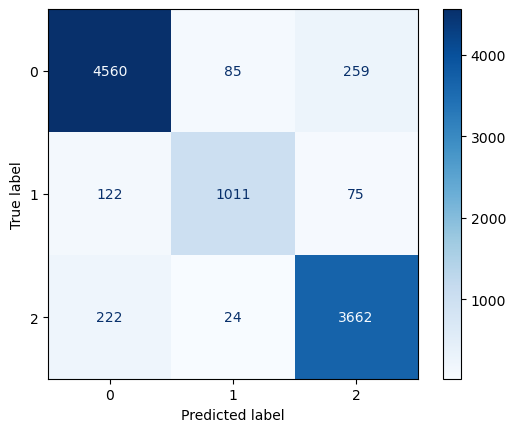

In [152]:
cmd=ConfusionMatrixDisplay(cm)
cmd.plot(cmap='Blues')
plt.show()

In [153]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc = accuracy_score(ytest, pred1)
rec = recall_score(ytest, pred1, average='weighted')
pre = precision_score(ytest, pred1, average='weighted')
f1 = f1_score(ytest, pred1, average='weighted')

In [154]:
print(f"Accuracy score:{acc}\nRecall Score:{rec}\nprecision score:{pre} \nf1_score:{f1}")

Accuracy score:0.9214570858283433
Recall Score:0.9214570858283433
precision score:0.921336434095915 
f1_score:0.9212021197389852
